In [2]:
pip install seaborn;

Note: you may need to restart the kernel to use updated packages.


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sns.set_theme(style='whitegrid')
print('Seaborn imported successfully')

Seaborn imported successfully


In [6]:
df = pd.DataFrame({
    'Gene': ['GeneA', 'GeneA', 'GeneB', 'GeneB', 'GeneC', 'GeneC', 'GeneD', 'GeneD'],
    'Condition': ['Control', 'Treatment'] * 4,
    'Expression': [5.2, 6.1, 2.1, 3.3, 7.8, 5.9, 4.4, 6.0],
    'Replicate': [1, 1, 1, 1, 1, 1, 1, 1]
})

df

,Gene,Condition,Expression,Replicate
0,GeneA,Control,5.2,1
1,GeneA,Treatment,6.1,1
2,GeneB,Control,2.1,1
3,GeneB,Treatment,3.3,1
4,GeneC,Control,7.8,1
5,GeneC,Treatment,5.9,1
6,GeneD,Control,4.4,1
7,GeneD,Treatment,6.0,1


Distribution plots

3.1 Histogram with histoplots()

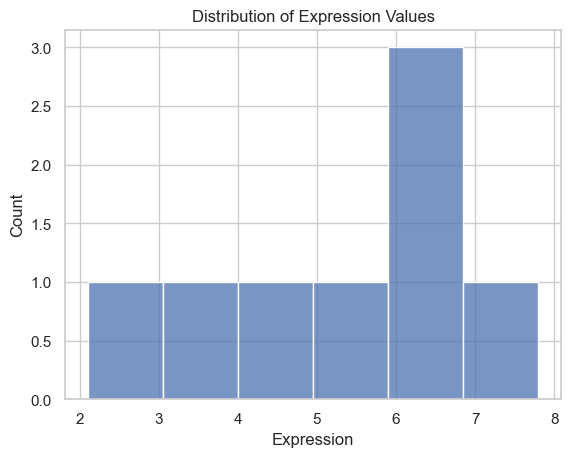

In [11]:
sns.histplot(data=df, x='Expression', bins=6)
plt.title('Distribution of Expression Values')
plt.show()

3.2 Smoothed density with kdeplot()

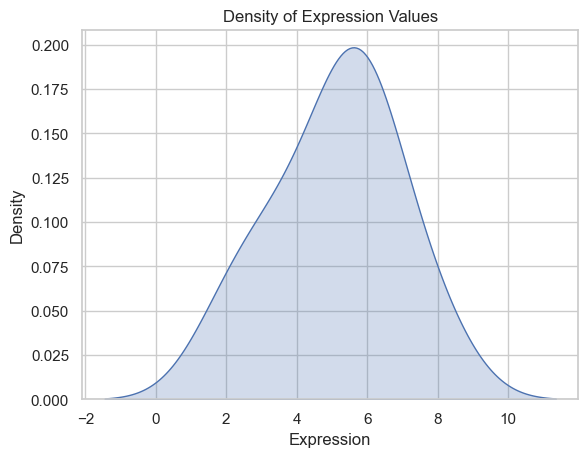

In [12]:
sns.kdeplot(data=df, x='Expression', fill=True)
plt.title('Density of Expression Values')
plt.show()

3.3 Compare distributions by group with displot()

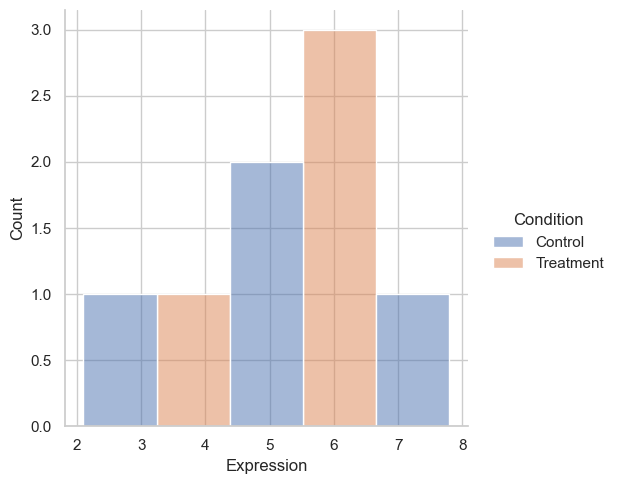

In [13]:
sns.displot(data=df, x='Expression', hue='Condition', kind='hist', bins=5)
plt.show()

In [15]:
bacteria_path = './bacteria.csv'

In [16]:
bacteria = pd.read_csv(bacteria_path)

In [17]:
bacteria.head()

,C1,C2,sample_id,species,Isolation origin,Phenotype,BSL,soln,carb_fit,cipro_fit,genta_fit,kan_fit,pip_fit,labels
0,7.895415,6.303232,A001,Escherichia coli,urine,Pathogenic strain,2,0.043922,0.833539,0.040470,0.429654,0.046829,0.857467,1
1,2.833671,6.823800,A002,Escherichia coli,blood,Pathogenic strain,2,0.098481,0.964883,0.110471,0.233285,0.000000,1.403835,6
2,3.178256,5.519982,A003,Escherichia coli,blood,Commensal strain,1,0.066501,0.498872,0.061445,0.564547,0.313546,0.368546,8
3,5.030077,4.642758,A004,Escherichia coli,feces,Pathogenic strain,2,0.116999,1.080682,0.101199,0.655379,0.305054,1.441512,0
4,2.691040,4.057780,A005,Escherichia coli,feces,Commensal strain,1,0.101523,0.272807,0.120601,0.186437,0.121745,0.398072,3


In [20]:
bacteria.shape

(50, 14)

A histogram of carb_fit

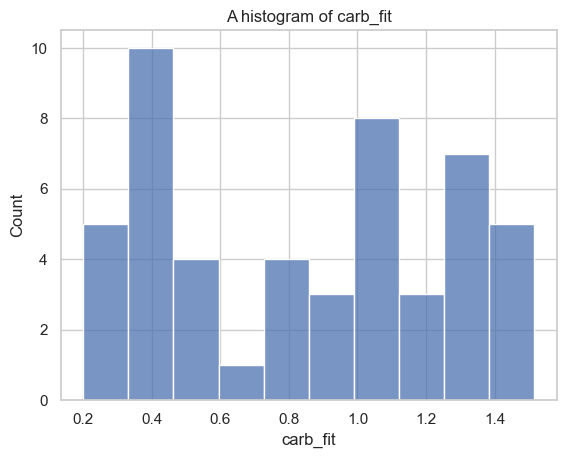

In [28]:
sns.histplot(data=bacteria, x="carb_fit", bins=10)
plt.title("A histogram of carb_fit")
plt.show()

A KDE plot of cipro_fit

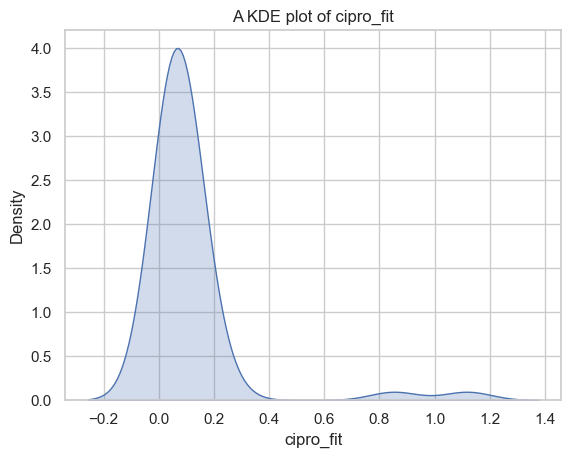

In [29]:
sns.kdeplot(data=bacteria, x='cipro_fit', fill=True)
plt.title("A KDE plot of cipro_fit")
plt.show()

A displot() grouped by Phenotype

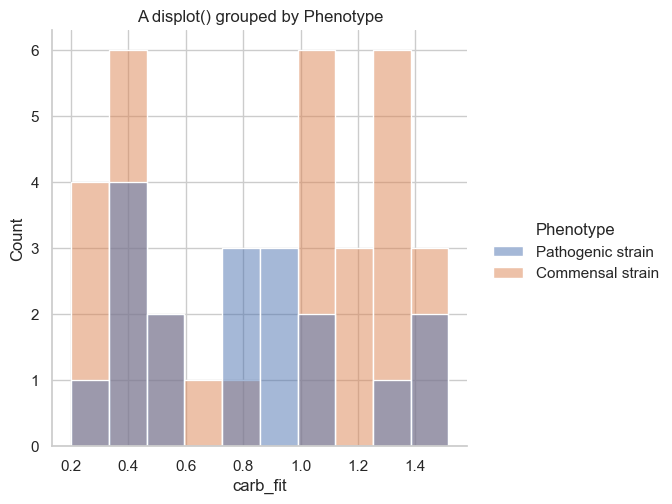

In [31]:
sns.displot(data=bacteria, x='carb_fit', hue='Phenotype', kind='hist', bins=10)
plt.title("A displot() grouped by Phenotype")
plt.show()

Scatter and Relationship Plots
Use these when you want to study relationships between variables.

In [32]:
growth = pd.DataFrame({
    'Time': [0, 2, 4, 6, 8, 0, 2, 4, 6, 8],
    'OD600': [0.05, 0.12, 0.24, 0.41, 0.60, 0.05, 0.15, 0.31, 0.52, 0.73],
    'Condition': ['Control'] * 5 + ['Treatment'] * 5
})

growth

,Time,OD600,Condition
0,0,0.05,Control
1,2,0.12,Control
2,4,0.24,Control
3,6,0.41,Control
4,8,0.60,Control
5,0,0.05,Treatment
6,2,0.15,Treatment
7,4,0.31,Treatment
8,6,0.52,Treatment
9,8,0.73,Treatment


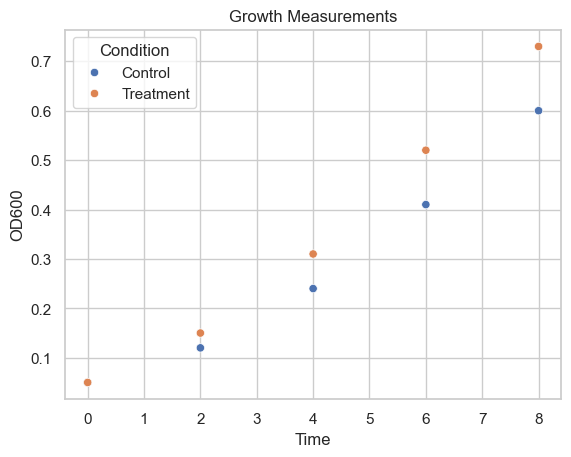

In [33]:
sns.scatterplot(data=growth, x='Time', y='OD600', hue='Condition')
plt.title('Growth Measurements')
plt.show()

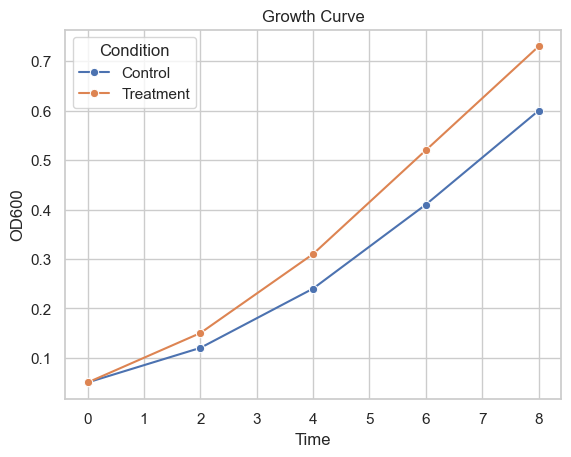

In [41]:
sns.lineplot(data=growth, x='Time', y='OD600', hue='Condition', marker='o')
plt.title('Growth Curve')
plt.show()

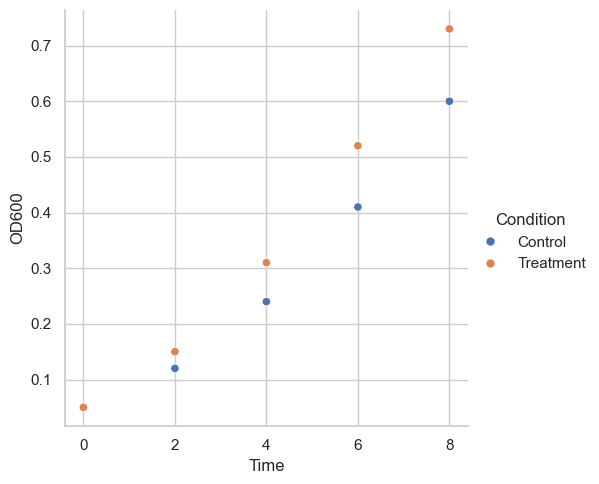

In [39]:
sns.relplot(data=growth, x='Time', y='OD600', hue='Condition', kind='scatter')
plt.show()

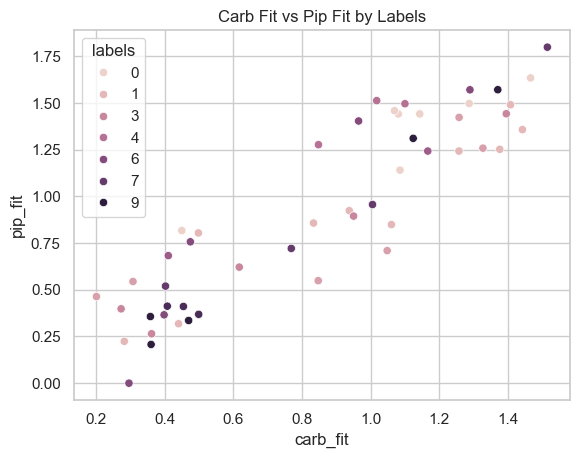

In [43]:
sns.scatterplot(data=bacteria, x='carb_fit', y='pip_fit', hue='labels')
plt.title('Carb Fit vs Pip Fit by Labels')
plt.show()

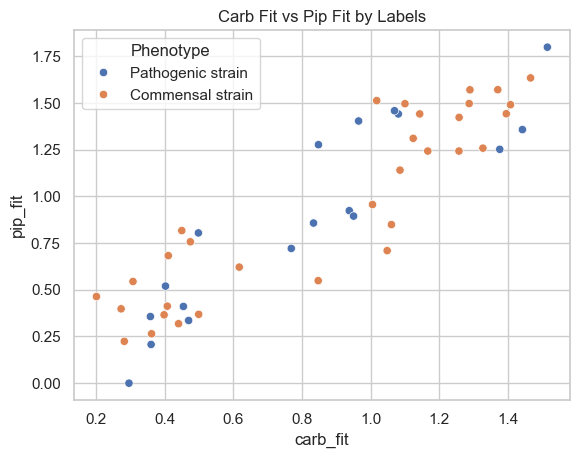

In [45]:
sns.scatterplot(data=bacteria, x='carb_fit', y='pip_fit', hue='Phenotype')
plt.title('Carb Fit vs Pip Fit by Labels')
plt.show()

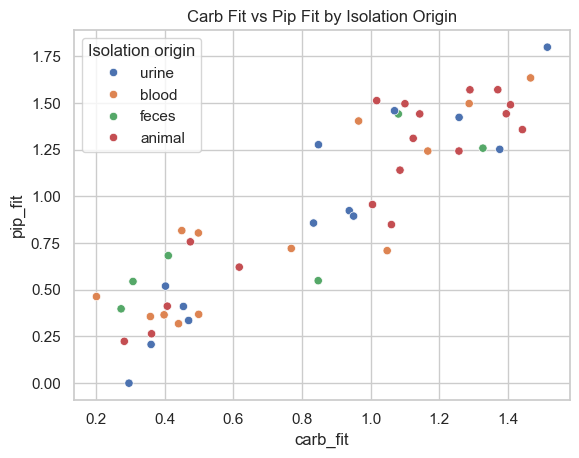

In [47]:
sns.scatterplot(data=bacteria, x='carb_fit', y='pip_fit', hue='Isolation origin')
plt.title('Carb Fit vs Pip Fit by Isolation Origin')
plt.show()

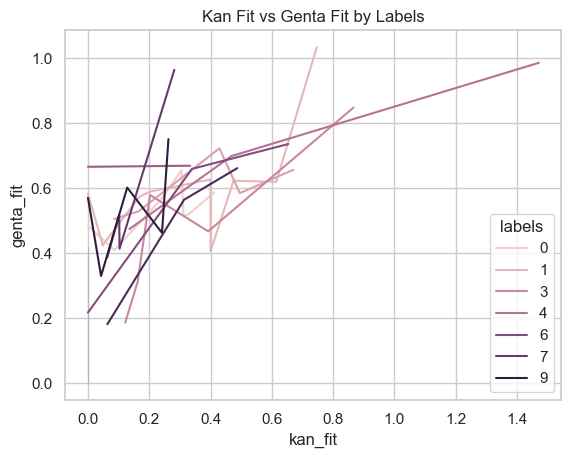

In [50]:
sns.lineplot(data=bacteria, x='kan_fit', y='genta_fit', hue='labels')
plt.title('Kan Fit vs Genta Fit by Labels')
plt.show()

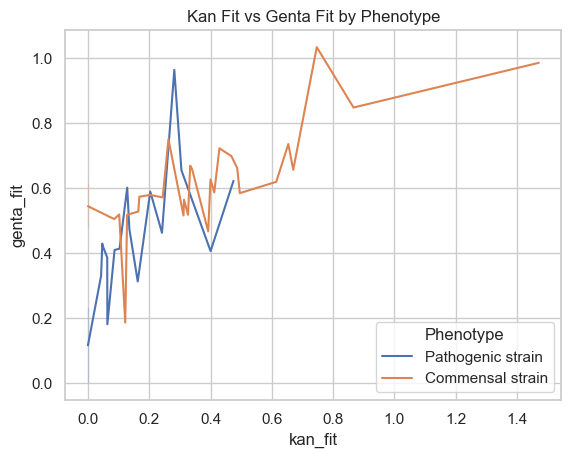

In [49]:
sns.lineplot(data=bacteria, x='kan_fit', y='genta_fit', hue='Phenotype')
plt.title('Kan Fit vs Genta Fit by Phenotype')
plt.show()

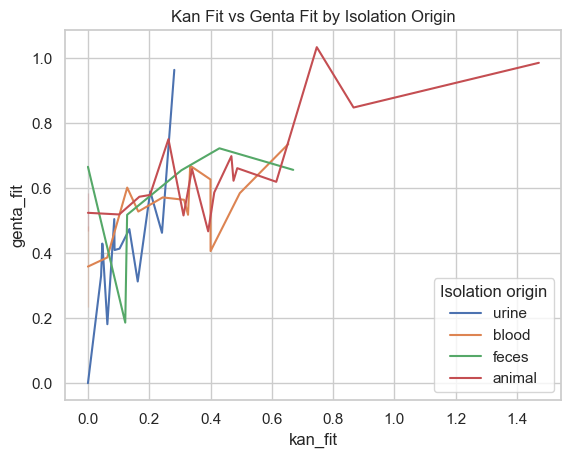

In [52]:
sns.lineplot(data=bacteria, x='kan_fit', y='genta_fit', hue='Isolation origin')
plt.title('Kan Fit vs Genta Fit by Isolation Origin')
plt.show()

 Categorical Plots
These are essential in biology when you compare measurements across genes, treatments, strains, or sample classes.

In [53]:
expr_rep = pd.DataFrame({
    'Gene': ['GeneA'] * 6 + ['GeneB'] * 6 + ['GeneC'] * 6,
    'Condition': ['Control', 'Control', 'Control', 'Treatment', 'Treatment', 'Treatment'] * 3,
    'Expression': [5.1, 5.3, 5.2, 6.0, 6.2, 6.1,
                   2.0, 2.3, 2.1, 3.0, 3.2, 3.1,
                   7.5, 7.9, 8.0, 5.7, 6.0, 6.1]
})

expr_rep.head()

,Gene,Condition,Expression
0,GeneA,Control,5.1
1,GeneA,Control,5.3
2,GeneA,Control,5.2
3,GeneA,Treatment,6.0
4,GeneA,Treatment,6.2


In [54]:
expr_rep

,Gene,Condition,Expression
0,GeneA,Control,5.1
1,GeneA,Control,5.3
2,GeneA,Control,5.2
3,GeneA,Treatment,6.0
4,GeneA,Treatment,6.2
5,GeneA,Treatment,6.1
6,GeneB,Control,2.0
7,GeneB,Control,2.3
8,GeneB,Control,2.1
9,GeneB,Treatment,3.0


In [ ]:
barplot()
Shows a summary value, usually the mean, with error bars.

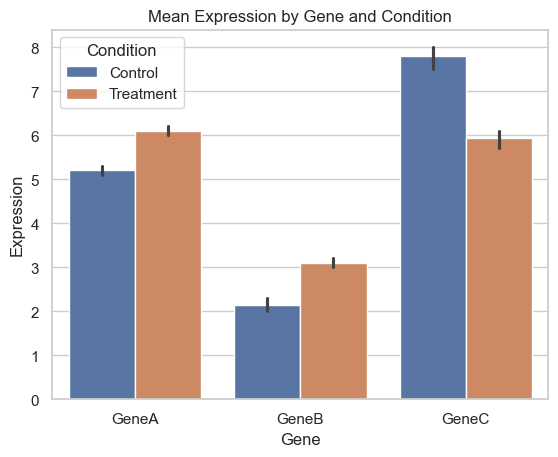

In [55]:
sns.barplot(data=expr_rep, x='Gene', y='Expression', hue='Condition')
plt.title('Mean Expression by Gene and Condition')
plt.show()

boxplot()
Shows median, quartiles, spread, and potential outliers.

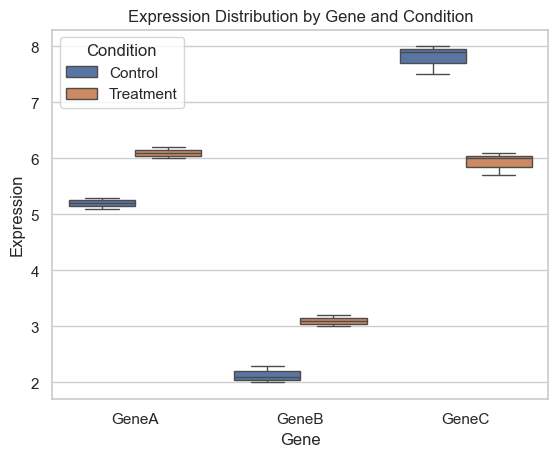

In [56]:
sns.boxplot(data=expr_rep, x='Gene', y='Expression', hue='Condition')
plt.title('Expression Distribution by Gene and Condition')
plt.show()

violinplot()
Shows the full shape of the distribution.

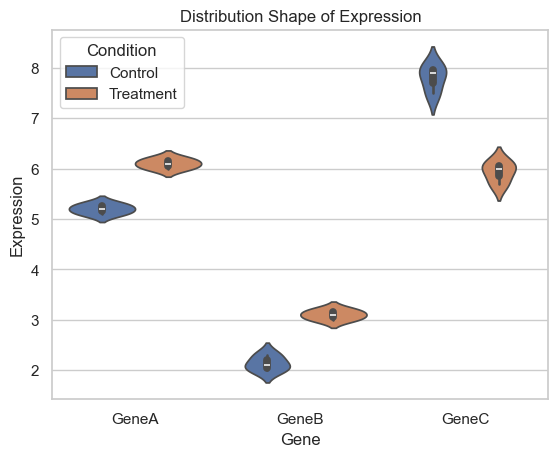

In [58]:
sns.violinplot(data=expr_rep, x='Gene', y='Expression', hue='Condition')
plt.title('Distribution Shape of Expression')
plt.show()

stripplot()
Shows raw data points.

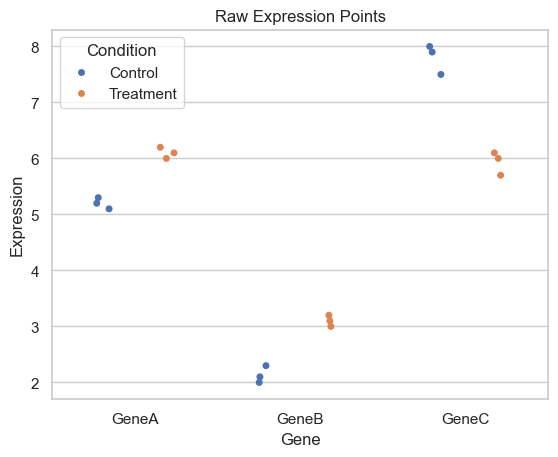

In [63]:
sns.stripplot(data=expr_rep, x='Gene', y='Expression', hue='Condition', dodge=True)
plt.title('Raw Expression Points')
plt.show()

swarmplot()
Similar to stripplot, but tries to avoid overlap.

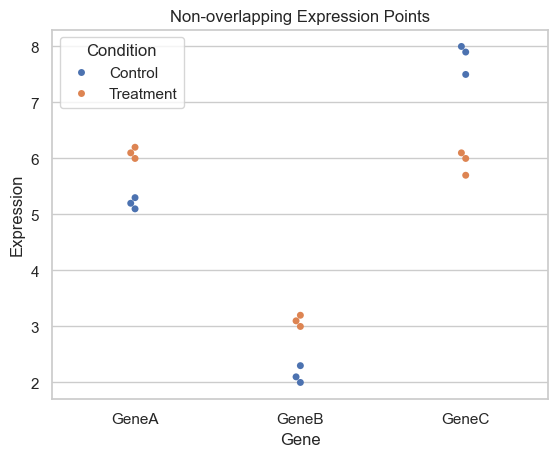

In [60]:
sns.swarmplot(data=expr_rep, x='Gene', y='Expression', hue='Condition')
plt.title('Non-overlapping Expression Points')
plt.show()

Overlaying summary and raw points
A very useful pattern in practice.

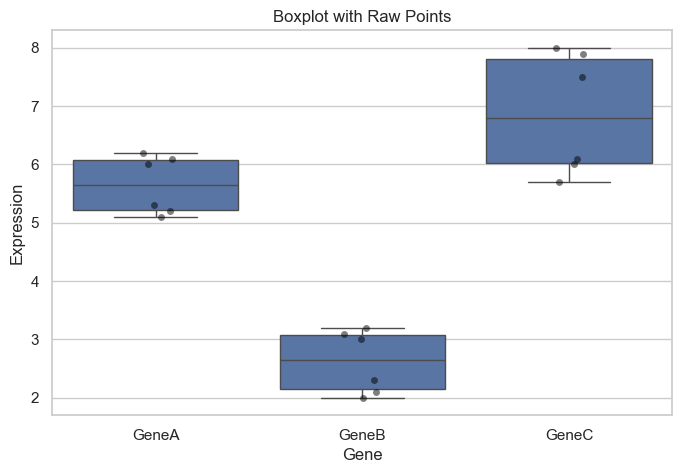

In [61]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=expr_rep, x='Gene', y='Expression')
sns.stripplot(data=expr_rep, x='Gene', y='Expression', color='black', alpha=0.5)
plt.title('Boxplot with Raw Points')
plt.show()

A bar plot grouped by labels

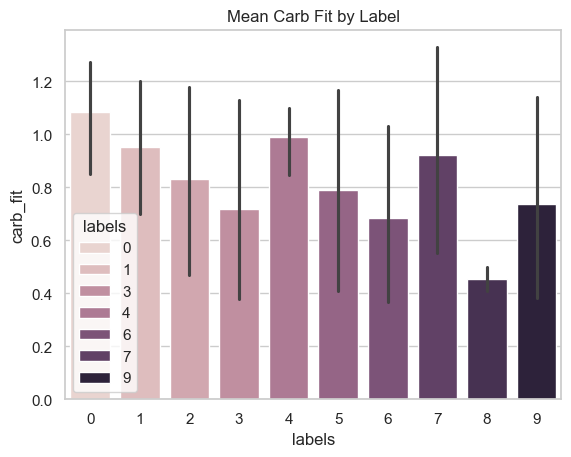

In [64]:
sns.barplot(data=bacteria, x='labels', y='carb_fit', hue='labels')
plt.title('Mean Carb Fit by Label')
plt.show()

A box plot grouped by Phenotypes

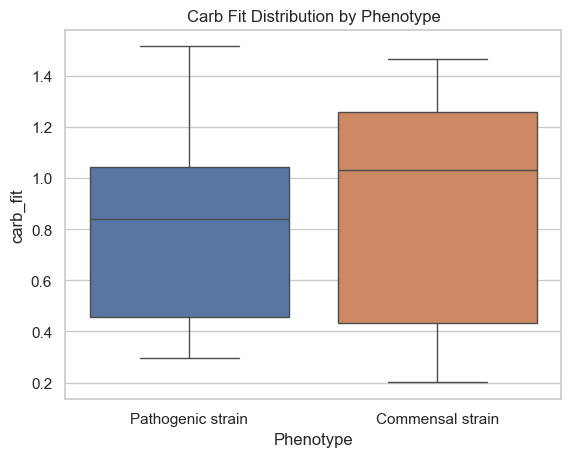

In [65]:
sns.boxplot(data=bacteria, x='Phenotype', y='carb_fit', hue='Phenotype')
plt.title('Carb Fit Distribution by Phenotype')
plt.show()

Violin plot grouped by Isolation origin

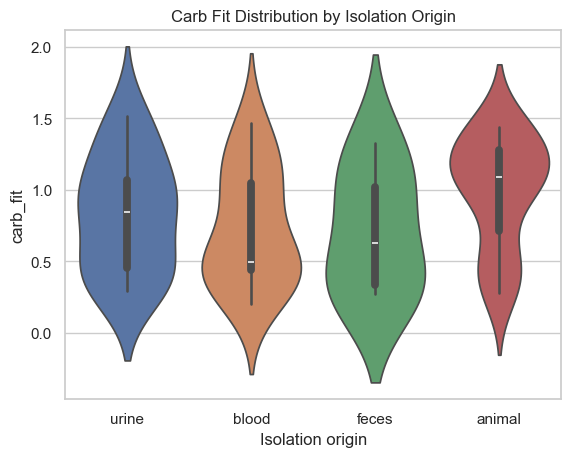

In [66]:
sns.violinplot(data=bacteria, x='Isolation origin', y='carb_fit', hue='Isolation origin')
plt.title('Carb Fit Distribution by Isolation Origin')
plt.show()

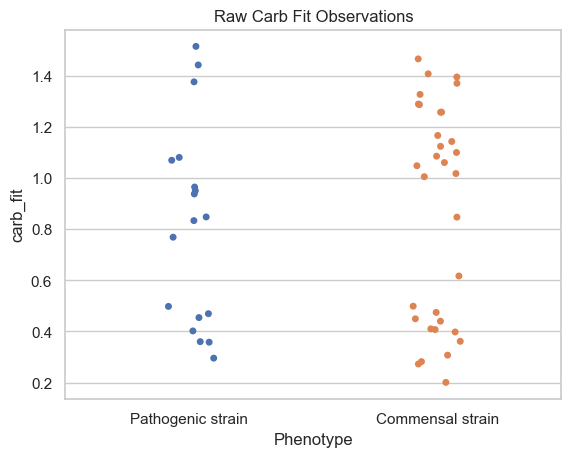

In [68]:
sns.stripplot(data=bacteria, x='Phenotype', y='carb_fit', hue='Phenotype', dodge=False)
plt.title('Raw Carb Fit Observations')
plt.show()

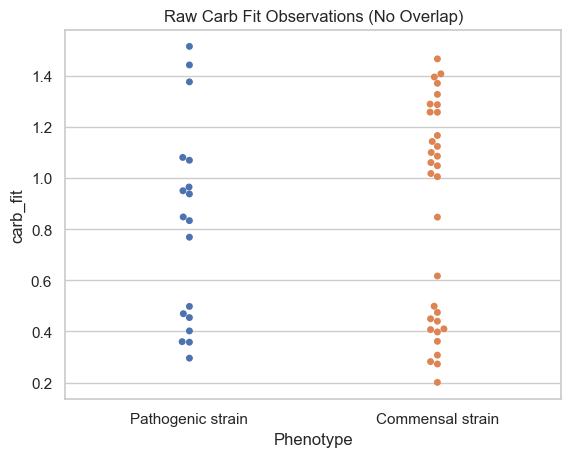

In [69]:
sns.swarmplot(data=bacteria, x='Phenotype', y='carb_fit', hue='Phenotype')
plt.title('Raw Carb Fit Observations (No Overlap)')
plt.show()

Pairwise Relationships with pairplot()
This is useful when you have multiple quantitative variables and want a quick overview.

In [70]:
cells = pd.DataFrame({
    'CellArea': [110, 115, 120, 130, 140, 150],
    'NucleusArea': [35, 38, 42, 45, 49, 55],
    'Intensity': [210, 220, 235, 240, 260, 275],
    'Condition': ['Control', 'Control', 'Control', 'Treatment', 'Treatment', 'Treatment']
})

cells

,CellArea,NucleusArea,Intensity,Condition
0,110,35,210,Control
1,115,38,220,Control
2,120,42,235,Control
3,130,45,240,Treatment
4,140,49,260,Treatment
5,150,55,275,Treatment


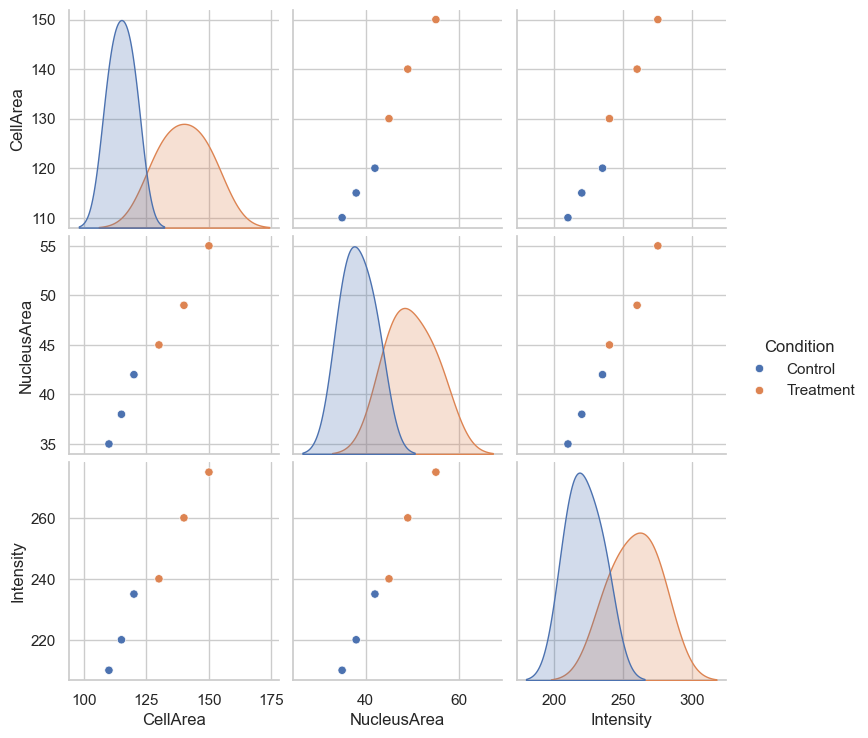

In [71]:
sns.pairplot(cells, hue='Condition')
plt.show()

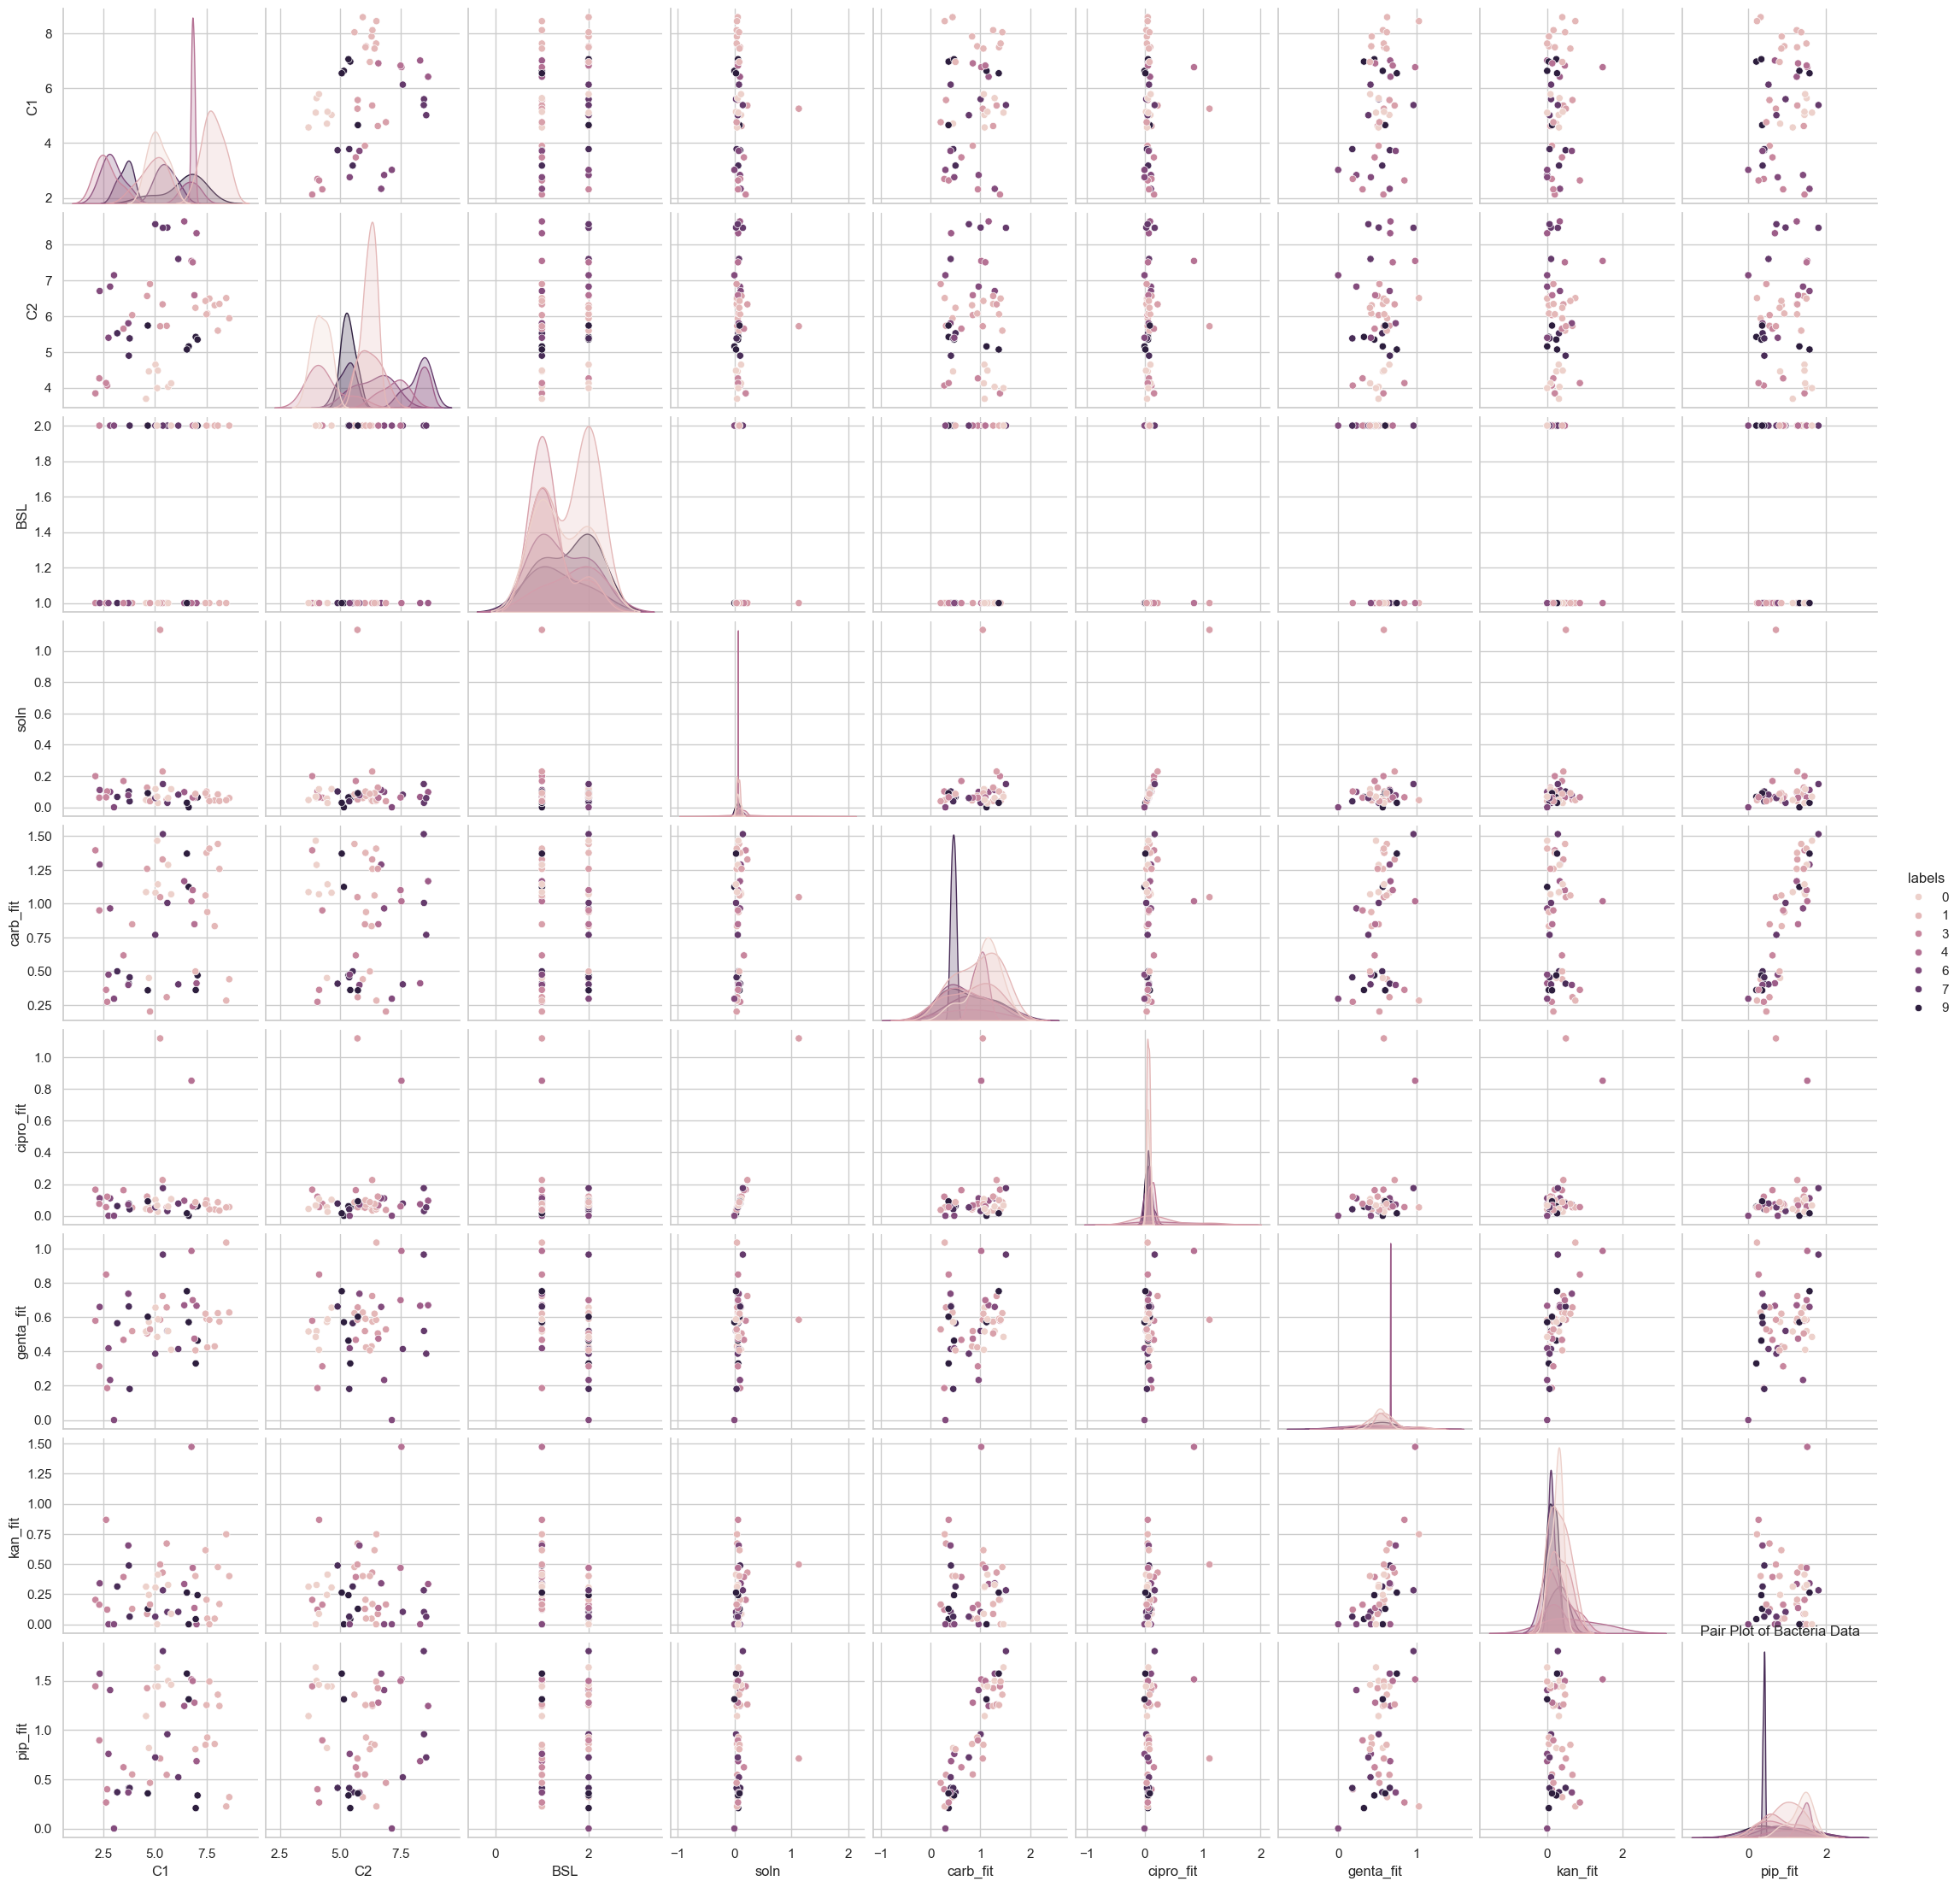

In [72]:
sns.pairplot(data=bacteria, hue='labels')
plt.title('Pair Plot of Bacteria Data')
plt.show()

Heatmaps
Heatmaps are critical for biology, especially for gene expression matrices.

In [73]:
heat_df = pd.DataFrame({
    'Gene': ['GeneA', 'GeneA', 'GeneB', 'GeneB', 'GeneC', 'GeneC'],
    'Condition': ['Control', 'Treatment'] * 3,
    'Expression': [5.2, 6.1, 2.1, 3.3, 7.8, 5.9]
})

matrix = heat_df.pivot(index='Gene', columns='Condition', values='Expression')
matrix

Condition,Control,Treatment
Gene,,
GeneA,5.2,6.1
GeneB,2.1,3.3
GeneC,7.8,5.9


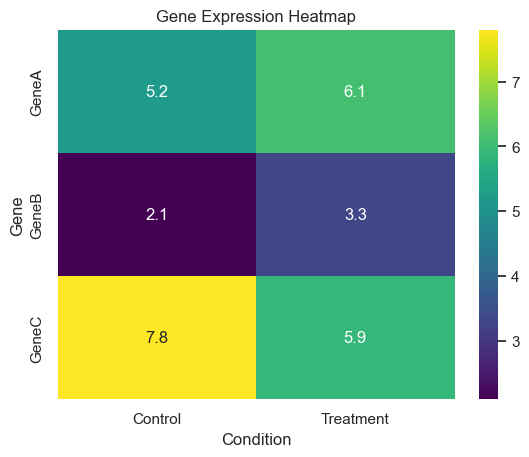

In [74]:
sns.heatmap(matrix, annot=True, cmap='viridis')
plt.title('Gene Expression Heatmap')
plt.show()

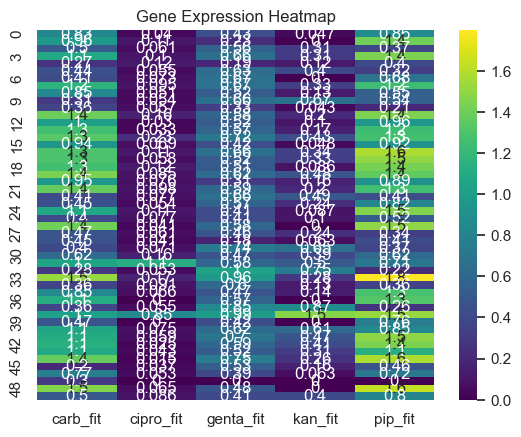

In [77]:

fitness_cols = ['carb_fit', 'cipro_fit', 'genta_fit', 'kan_fit', 'pip_fit']
matrix = bacteria[fitness_cols]


sns.heatmap(matrix, annot=True, cmap='viridis')
plt.title('Gene Expression Heatmap')
plt.show()

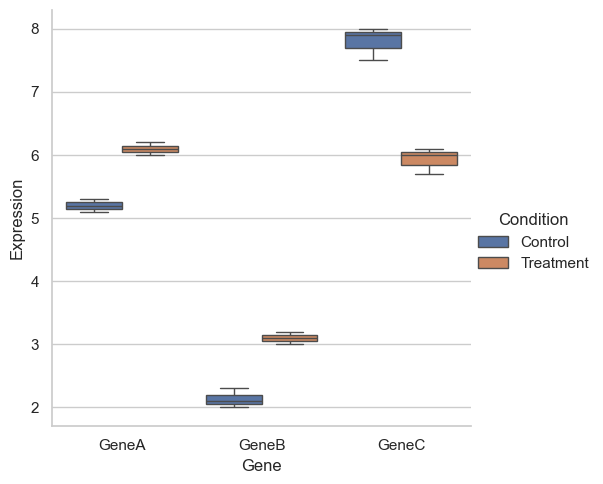

In [75]:
sns.catplot(data=expr_rep, x='Gene', y='Expression', hue='Condition', kind='box')
plt.show()

Box plot of Expression by Gene

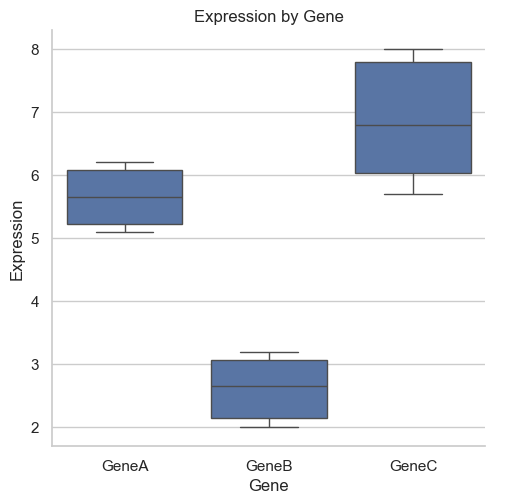

In [78]:
sns.catplot(data=expr_rep, x='Gene', y='Expression', kind='box')
plt.title('Expression by Gene')
plt.show()

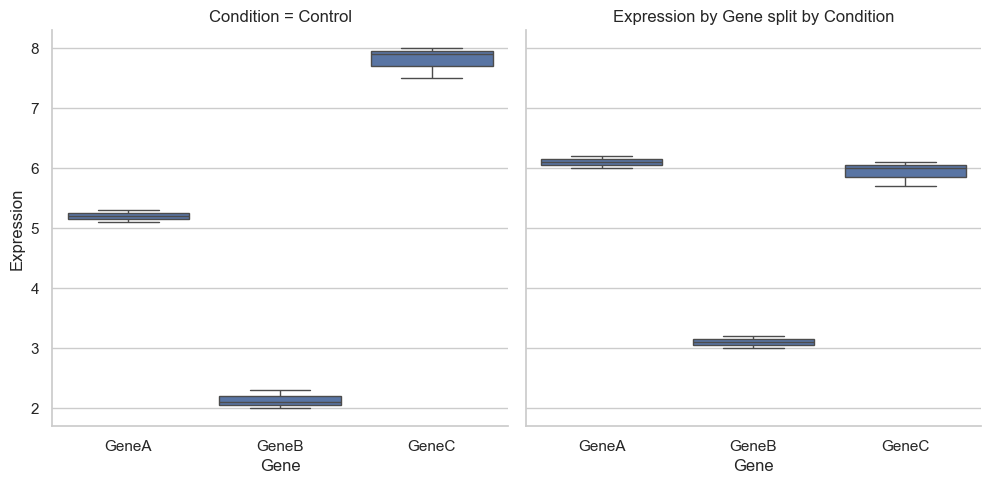

In [79]:
sns.catplot(data=expr_rep, x='Gene', y='Expression', col='Condition', kind='box')
plt.title('Expression by Gene split by Condition')
plt.show()